In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matrix
import base

In [2]:
A,x,y = matrix.random_dist_matrix(20,0,30)

In [3]:
# To do:
    #* Kontrollieren ob die Codes das richtige machen-> Speziell double_side & nearest Intersection
    #* bei nearest intersection überprüfen ob man den Zufallsstart irgendwie verbessern kann 
    #        -> bei mehreren versuchen anderes Ergebnis
    #* Brauchen wir Double-ended nearest and loneliest neighbour

In [4]:
def Nearest_Neighbor(points,distance,start):
    """
        Calculate way with minial distance through Nearest_Neighbor algorithm with given start point
        Input: points - points of interests - integer array from 0-#cities-1
               distances - 2d-matrix containing the distances
               start- startpoint - integer
        Output: way with minimal_distances- by Nearest_Neighbor algorithm
    
    """
    way = np.array([start]) # start with startpoint
    
    while len(way) != len(points):
        min_dist = np.max(distance)+1
        
        for  i in range(len(points)):
            
            if (A[way[-1],i] < min_dist) and (i not in way):
                # minimal distance and not yet visited city
                min_dist = A[way[-1],i]
                new_point = i
        way = np.append(way,new_point)
        
    way = np.append(way,start) # end with startpoint
    return way   

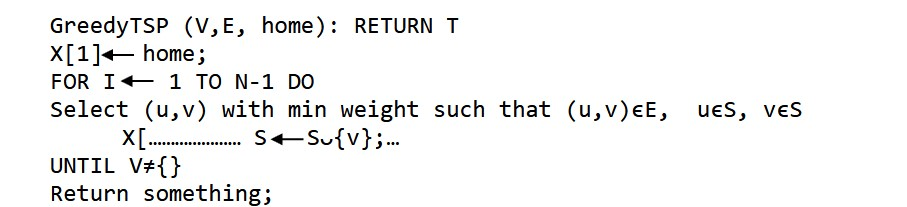

In [4]:
points = np.arange(len(A))
zero_start = Nearest_Neighbor(points,A,0)

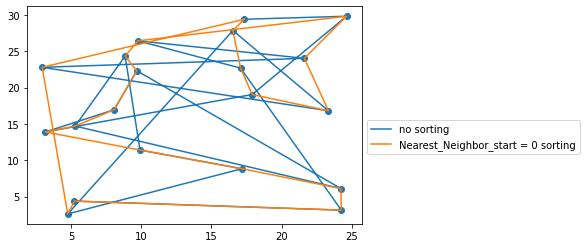

In [5]:
plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[zero_start],y[zero_start], label ='Nearest_Neighbor_start = 0 sorting')
plt.legend( bbox_to_anchor=(1, 0.5))

In [6]:

def Nearest_Neighbor_all_start(points,distance):
    """
        Calculate way with minial distance through Nearest_Neighbor algorithm
        Input: points - points of interests - integer array from 0-#cities-1
               distances - 2d-matrix containing the distances
        Output: way with minimal_distances- by Nearest_Neighbor algorithm
                minimal_distance
    
    """
    way = points
    min_dist = base.totalTravelDist(points,distance)
    for j in range(len(points)): # go through all points
        new_way = Nearest_Neighbor(points,distance,j)
        new_dist = base.totalTravelDist(new_way,distance)
        if new_dist < min_dist:
            min_dist = new_dist
            way = new_way
    return (way,min_dist)
        
    

In [7]:
Nearest_Neighbor_min,Nearest_Neighbor_dist = Nearest_Neighbor_all_start(points,A)

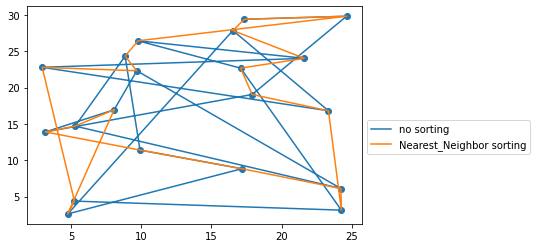

In [8]:
plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[Nearest_Neighbor_min],y[Nearest_Neighbor_min], label ='Nearest_Neighbor sorting')
plt.legend( bbox_to_anchor=(1, 0.5))

In [9]:
mc_min_Nearest_Neighbor_tries, mc_dist_Nearest_Neighbor_tries = base.traveling_MC_constDist(points,A,len(points))[0:2]

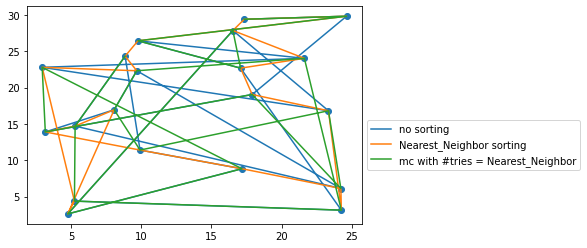

In [10]:
plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[Nearest_Neighbor_min],y[Nearest_Neighbor_min], label ='Nearest_Neighbor sorting')
plt.plot(x[mc_min_Nearest_Neighbor_tries],y[mc_min_Nearest_Neighbor_tries], label ='mc with #tries = Nearest_Neighbor')
plt.legend( bbox_to_anchor=(1, 0.5))

In [11]:
mc_min,mc_dist = base.traveling_MC_constDist(points,A,10000)[0:2]

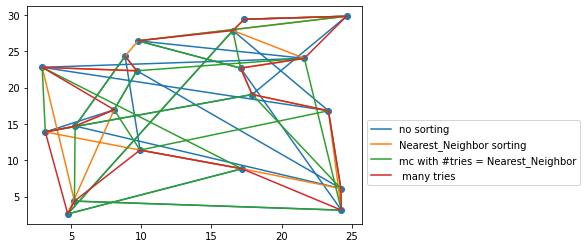

In [12]:
plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[Nearest_Neighbor_min],y[Nearest_Neighbor_min], label ='Nearest_Neighbor sorting')
plt.plot(x[mc_min_Nearest_Neighbor_tries],y[mc_min_Nearest_Neighbor_tries], label ='mc with #tries = Nearest_Neighbor')
plt.plot(x[mc_min],y[mc_min], label =' many tries')
plt.legend( bbox_to_anchor=(1, 0.5))

In [13]:
# Result from distances
print("Nearest_Neighbor-distance",Nearest_Neighbor_dist)
print("mc_dist_Nearest_Neighbor_tries",mc_dist_Nearest_Neighbor_tries[-1])
print("mc_dist much more tries",mc_dist[-1])

Nearest_Neighbor-distance 136.36208844901532
mc_dist_Nearest_Neighbor_tries 255.93625427605772
mc_dist much more tries 113.87474395637038


In [14]:
%%timeit
Nearest_Neighbor_all_start(points,A)

27.9 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
%%timeit
base.traveling_MC_constDist(points,A,len(points))

1.51 ms ± 21.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [16]:
%%timeit
base.traveling_MC_constDist(points,A,10000)

C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


788 ms ± 59.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Conclusion
The Nearest-Neighbor-algorithm is a fast algorithm, but it don't have to lead to the fastest path.

# Double_side_Nearest_Neighbor

Nearest neighbour von beiden Seiten ? habe ich das richtig verstanden?

In [17]:
def Double_side_Nearest_Neighbor(points,distance,start):
    """
        Calculate way with minial distance through Double_side_Nearest_Neighbor algorithm with given start point:
        nearest neighbour from left and right.
        Input: points - points of interests - integer array from 0-#cities-1
               distances - 2d-matrix containing the distances
               start- startpoint - integer
        Output: way with minimal_distances- by Double_side_Nearest_Neighbor algorithm
    
    """
    way_right = np.array([start]) # start with startpoint
    way_left = np.array([start])
    used = np.array([start]) # used 
    while (len(way_right)+len(way_left)-1) < len(points):
        min_dist = np.max(distance)+1
        
        for  i in range(len(points)):
            
            if (A[way_right[-1],i] < min_dist) and (i not in used):
                # minimal distance and not yet visited city
                min_dist = A[way_right[-1],i]
                new_point = i
        way_right = np.append(way_right,new_point)
        used = np.append(used,new_point)
        min_dist = np.max(distance)+1
        if len(used) != len(points):
            for  i in range(len(points)):

                if (A[way_left[-1],i] < min_dist) and (i not in used):
                    # minimal distance and not yet visited city
                    min_dist = A[way_left[-1],i]
                    new_point = i
            way_left = np.append(new_point,way_left)
            used = np.append(used,new_point)
    way = np.append(way_right,way_left) # end with startpoint
    return way  

In [18]:
d_zero=Double_side_Nearest_Neighbor(points,A,0)

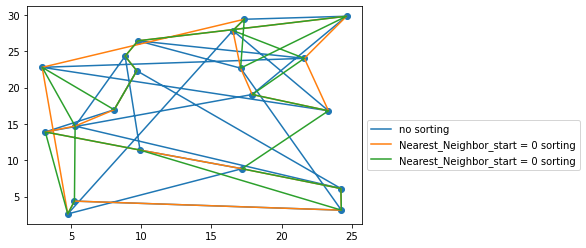

In [19]:
plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[zero_start],y[zero_start], label ='Nearest_Neighbor_start = 0 sorting')
plt.plot(x[d_zero],y[d_zero], label ='Nearest_Neighbor_start = 0 sorting')
plt.legend( bbox_to_anchor=(1, 0.5))

In [20]:
def Double_side_Nearest_Neighbor_all_start(points,distance):
    """
        Calculate way with minial distance through Double_side_Nearest_Neighbor algorithm
        Input: points - points of interests - integer array from 0-#cities-1
               distances - 2d-matrix containing the distances
        Output: way with minimal_distances- by Nearest_Neighbor algorithm
                minimal_distance
    
    """
    way = points
    min_dist = base.totalTravelDist(points,distance)
    for j in range(len(points)): # go through all points
        new_way = Double_side_Nearest_Neighbor(points,distance,j)
        new_dist = base.totalTravelDist(new_way,distance)
        if new_dist < min_dist:
            min_dist = new_dist
            way = new_way
    return (way,min_dist)

In [21]:
d_Nearest_Neighbor_min,d_Nearest_Neighbor_dist = Double_side_Nearest_Neighbor_all_start(points,A)

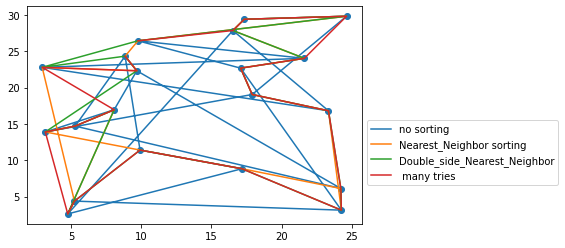

In [22]:
plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[Nearest_Neighbor_min],y[Nearest_Neighbor_min], label ='Nearest_Neighbor sorting')
plt.plot(x[d_Nearest_Neighbor_min],y[d_Nearest_Neighbor_min], label ='Double_side_Nearest_Neighbor')
plt.plot(x[mc_min],y[mc_min], label =' many tries')
plt.legend( bbox_to_anchor=(1, 0.5))

In [23]:
print("Nearest_Neighbor-distance",Nearest_Neighbor_dist)
print("Double_side_Nearest_Neighbor-distance",d_Nearest_Neighbor_dist)

Nearest_Neighbor-distance 136.36208844901532
Double_side_Nearest_Neighbor-distance 133.04759894306054


# Double-ended nearest and loneliest neighbour heuristic
## Siehe DENLN_Heuristic paper Kapitel.3

In a pre-processing step that runs in a negligible time, a new distance matrix is obtained such
that shorter new distances from a city to others are an equally weighted function of both
shorter old distances to those cities and a higher loneliness of that city.

In [24]:
def average_dist(distance):
    """
        Pre-processing of the distance Matrix to see wich matrix is in average farther away
        Input: distance 2d-matrix
        Output: Distance matrix, which priotize matrices, which are further away
    """
    
    N = len(distance)
    A = np.zeros((N,N))
    x = np.zeros(N)
    for i in range(N):
        x[i] = np.mean(distance[i,:])
    min_dist_points = np.min(x) 
    max_dist_points = np.max(x)
    average_dist = (max_dist_points + min_dist_points)/2
    for i in range(N):
        if (x[i] > average_dist):
            x[i] = average_dist- (x[i] - average_dist);
        else:
            x[i]=average_dist + (average_dist - x[i] )
    for i in range(N):
        for j in range(N): 
            A[i][j]=((N*distance[i][j])+ x[j])/2;
    return A

In [25]:
B =average_dist(A)

In [26]:
lonely_Nearest_Neighbor_min, lonely_Nearest_Neighbor_dist = Nearest_Neighbor_all_start(points,B)
lonely_Nearest_Neighbor_dist = base.totalTravelDist(lonely_Nearest_Neighbor_min,A)
d_lonely_Nearest_Neighbor_min, d_lonely_Nearest_Neighbor_dist = Double_side_Nearest_Neighbor_all_start(points,B)
d_lonely_Nearest_Neighbor_dist = base.totalTravelDist(d_lonely_Nearest_Neighbor_min,A)

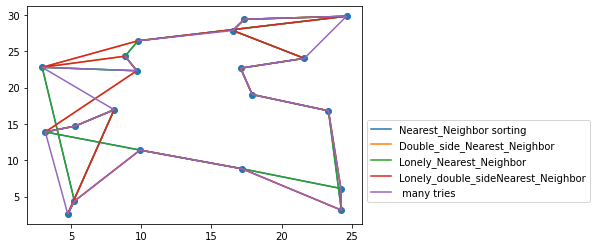

In [27]:
#plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
plt.plot(x[Nearest_Neighbor_min],y[Nearest_Neighbor_min], label ='Nearest_Neighbor sorting')
plt.plot(x[d_Nearest_Neighbor_min],y[d_Nearest_Neighbor_min], label ='Double_side_Nearest_Neighbor')
plt.plot(x[lonely_Nearest_Neighbor_min],y[lonely_Nearest_Neighbor_min], label ='Lonely_Nearest_Neighbor')
plt.plot(x[d_lonely_Nearest_Neighbor_min],y[d_lonely_Nearest_Neighbor_min], label ='Lonely_double_sideNearest_Neighbor')
plt.plot(x[mc_min],y[mc_min], label =' many tries')
plt.legend( bbox_to_anchor=(1, 0.5))

In [28]:
print("Nearest_Neighbor-distance",Nearest_Neighbor_dist)
print("Double_side_Nearest_Neighbor-distance",d_Nearest_Neighbor_dist)
print("Lonely_Nearest_Neighbor-distance",lonely_Nearest_Neighbor_dist)
print("Lonely_double_sideNearest_Neighbor-distance",d_lonely_Nearest_Neighbor_dist)
print("mc_dist much more tries",mc_dist[-1])

Nearest_Neighbor-distance 136.36208844901532
Double_side_Nearest_Neighbor-distance 133.04759894306054
Lonely_Nearest_Neighbor-distance 136.36208844901532
Lonely_double_sideNearest_Neighbor-distance 133.04759894306054
mc_dist much more tries 113.87474395637038


# Nearest Insertion

1.We're looking to construct a cycle $C$ containing all the nodes of our problem. We will do this by initially constructing a small cycle and slowly adding nodes to it until it contains all the nodes. We start by choosing some starting node $N$ and adding it to $C$. $C$ now contains a single node, $N$

2.
We want to add to $C$
the node which will increase its length the least. To do this we need to find which node to add to our cycle and then figure out where in the cycle to put it. We select this node by choosing the node (not in $C$) which is the closest to any node in $C$. We then insert this node between two nodes in $C$ such that the increase in length is minimal. More formally: Let $k$ be the node we selected. Find an edge $(i,j)$ such that $d_{ik}+d_{kj}−d_{ij}$ is minimal.
3.
Add $k$ to $C$, remove edge $(i,j)$, and add edges $(i,k)$ and $(k,j)$

4.If $C$ contains all the nodes, stop. Otherwise, go to 2.

In [63]:
def nearest_Insertion(distance):
    """
        Implementation of nearest Insertion method: inserting nodes to cycle, so that length increase is minimal
        Input: distance 2d-matrix
        Output: samllest path regarding nearest Insertion method
    
    """
    
    N = len(distance)
    
    points = np.arange(N)
    x,y = np.random.choice(points, size=2, replace=False)
    cycle = np.array([x,y])
    while len(cycle) <N:
        d = np.max(distance)
        for c in range(len(cycle)-1):
            pos1 = cycle[c]
            pos2 = cycle[c+1]
            for j in range(N):
                if j not in cycle:
                    if distance[pos1,j]+distance[j,pos2]-distance[pos1,pos2] <d:
                        d = distance[pos1,j]+distance[j,pos2]-distance[pos1,pos2] 
                        k = j
                        rep_c = c+1
        cycle = np.insert(cycle,rep_c,k)

    cycle = np.append(cycle,cycle[0])
    return cycle
            

In [64]:
nearest_insertion_min = nearest_Insertion(A)
dist_nearest_insertion = base.totalTravelDist(nearest_insertion_min,A)

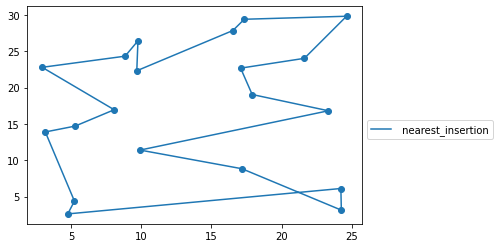

In [65]:
#plt.plot(x,y,label = 'no sorting')
plt.scatter(x,y)
#plt.plot(x[Nearest_Neighbor_min],y[Nearest_Neighbor_min], label ='Nearest_Neighbor sorting')
#plt.plot(x[d_Nearest_Neighbor_min],y[d_Nearest_Neighbor_min], label ='Double_side_Nearest_Neighbor')
#plt.plot(x[lonely_Nearest_Neighbor_min],y[lonely_Nearest_Neighbor_min], label ='Lonely_Nearest_Neighbor')
#plt.plot(x[d_lonely_Nearest_Neighbor_min],y[d_lonely_Nearest_Neighbor_min], label ='Lonely_double_sideNearest_Neighbor')
plt.plot(x[nearest_insertion_min],y[nearest_insertion_min], label =' nearest_insertion')
#plt.plot(x[mc_min],y[mc_min], label =' many tries')
plt.legend( bbox_to_anchor=(1, 0.5))

In [66]:
print("Nearest_Neighbor-distance",Nearest_Neighbor_dist)
print("Double_side_Nearest_Neighbor-distance",d_Nearest_Neighbor_dist)
print("Lonely_Nearest_Neighbor-distance",lonely_Nearest_Neighbor_dist)
print("Lonely_double_sideNearest_Neighbor-distance",d_lonely_Nearest_Neighbor_dist)
print("Nearest Insertion",dist_nearest_insertion)
print("mc_dist much more tries",mc_dist[-1])

Nearest_Neighbor-distance 136.36208844901532
Double_side_Nearest_Neighbor-distance 133.04759894306054
Lonely_Nearest_Neighbor-distance 136.36208844901532
Lonely_double_sideNearest_Neighbor-distance 133.04759894306054
Nearest Insertion 130.52674642552054
mc_dist much more tries 113.87474395637038


# Conclusion
From the greedy heuristics the Nearest Insertion seems the best, but still don't give the smallest path possible